# Unsupervised Learning: Clustering

In [131]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [132]:
df = pd.read_csv(r'C:\Users\aldiv\Downloads\CV\CV\Portofolio Data Science\Mini Project 3 Predict Customer Personality to Boost Marketing Campaign by Using Machine Learning\Data Preprocessing\3. Modelling.csv')
print(f'Number of columns: {df.shape[1]}')
print(f'Number of rows: {df.shape[0]}\n')
print(f'Missing value: \n{df.isna().sum()}')
print(f'\nDuplicated Data: {df.duplicated().sum()}')

Number of columns: 36
Number of rows: 2056

Missing value: 
Education               0
Kid                     0
Teen                    0
Recency                 0
Deals_Purchases         0
Web_Purchases           0
Catalog_Purchases       0
Store_Purchases         0
Web_Visits              0
Campaign_3              0
Campaign_4              0
Campaign_5              0
Campaign_1              0
Campaign_2              0
Complain                0
Response                0
Enroll_day              0
Enroll_month            0
Enroll_year             0
Enroll_tenure (days)    0
Total_Spending          0
Income                  0
Coke                    0
Fruits                  0
Meat                    0
Fish                    0
Sweet                   0
Gold                    0
Status__Bertunangan     0
Status__Cerai           0
Status__Lajang          0
Status__Menikah         0
Age                     0
Total_Spending_log      0
Children                0
is_parent               0
dtyp

In [133]:
df_model = df.copy()
df_model.drop(columns=['Total_Spending'], axis=1, inplace=True)
original_indices = df_model.index
print(f'Before drop duplicates: {df_model.duplicated().sum()}')
df_model.drop_duplicates(inplace=True)
print(f'After drop duplicates: {df_model.duplicated().sum()}')

Before drop duplicates: 1
After drop duplicates: 0


There are 2.056 rows and 35 columns. Since the columns are too many, there will be many problems. But, many features are correlated and hence redundant. To solve this problem, dimensionality reduction is needed. One of the method is **Principle Component Analysis**

**Principle Component Analysis** is a technique for reducing the dimensionality of the dataset without removing features. Unlike feature selection, PCA can minimizing loss information but increasing interpretability of data

# Principle Component Analysis (PCA)

In [134]:
pd.set_option('Display.max_columns', None)
df_model.describe()

,Education,Kid,Teen,Recency,Deals_Purchases,Web_Purchases,Catalog_Purchases,Store_Purchases,Web_Visits,Campaign_3,Campaign_4,Campaign_5,Campaign_1,Campaign_2,Complain,Response,Enroll_day,Enroll_month,Enroll_year,Enroll_tenure (days),Income,Coke,Fruits,Meat,Fish,Sweet,Gold,Status__Bertunangan,Status__Cerai,Status__Lajang,Status__Menikah,Age,Total_Spending_log,Children,is_parent
count,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000
mean,2.462774,0.445255,0.509002,0.000201,2.337226,4.099270,2.663260,5.773723,5.318248,0.072993,0.076886,0.072019,0.065693,0.012652,0.009732,0.151338,15.673479,6.460827,-0.000687,0.000749,17.662450,11.493374,7.779996,10.981145,8.131933,7.719135,9.741309,0.253041,0.140633,0.219465,0.386861,0.000171,0.000430,0.954258,0.719221
std,1.005560,0.537581,0.546558,1.000445,1.943118,2.797947,2.935278,3.239828,2.440915,0.260188,0.266475,0.258583,0.247806,0.111795,0.098195,0.358465,8.806088,3.504108,1.000001,0.999909,0.503538,2.048569,3.863118,1.644997,3.959341,3.945558,2.092153,0.434860,0.347727,0.413985,0.487150,1.000457,1.000296,0.748806,0.449489
min,0.000000,0.000000,0.000000,-1.690201,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,-1.505816,-1.743052,14.363633,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.272960,-3.097268,0.000000,0.000000
25%,2.000000,0.000000,0.000000,-0.862126,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,3.000000,-0.046835,-0.857466,17.390507,10.043293,6.908755,9.680406,8.006701,6.908755,9.105091,0.000000,0.000000,0.000000,0.000000,-0.686331,-0.604830,0.000000,0.000000
50%,2.000000,0.000000,0.000000,0.000453,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,6.000000,-0.046835,-0.001564,17.754789,12.066816,8.987322,11.112463,9.392745,8.987322,10.085851,0.000000,0.000000,0.000000,0.000000,-0.101784,0.124569,1.000000,1.000000
75%,3.000000,1.000000,1.000000,0.863032,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,10.000000,1.412146,0.869180,18.038116,13.131325,10.404293,12.345839,10.819798,10.434145,10.933125,1.000000,0.000000,0.000000,1.000000,0.816790,0.883464,1.000000,1.000000
max,4.000000,2.000000,2.000000,1.725611,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,31.000000,12.000000,1.412146,1.715186,18.905555,14.216299,12.201065,14.360738,12.464587,12.479913,12.799402,1.000000,1.000000,1.000000,1.000000,6.328237,1.489794,3.000000,1.000000


In [135]:
from sklearn.decomposition import PCA
pcs = PCA(n_components=4).fit_transform(df_model)
pdf = pd.DataFrame(data=pcs, columns= ['pc1', 'pc2', 'pc3', 'pc4'])
pdf.describe().T

,count,mean,std,min,25%,50%,75%,max
pc1,2055.0,6.085427e-16,8.808025,-14.858892,-7.666433,0.293395,7.332435,15.506857
pc2,2055.0,3.658171e-15,6.720700,-17.081093,-4.333577,0.219362,6.031563,11.778120
pc3,2055.0,1.448747e-15,3.680566,-10.439149,-2.579406,-0.137346,2.472140,15.590276
pc4,2055.0,1.230916e-15,3.577118,-8.229099,-2.905139,0.075429,2.874693,10.778507


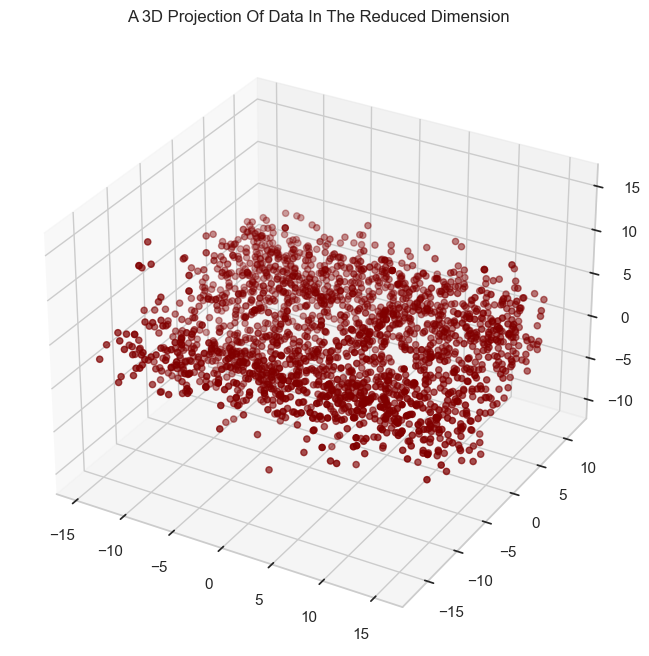

In [136]:
#A 3D Projection Of Data In The Reduced Dimension
x =pdf["pc1"]
y =pdf["pc2"]
z =pdf["pc3"]
a = pdf["pc4"]
#To plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y, z, c="maroon", marker="o" )
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

# Elbow Method
To find the best cluster (k)

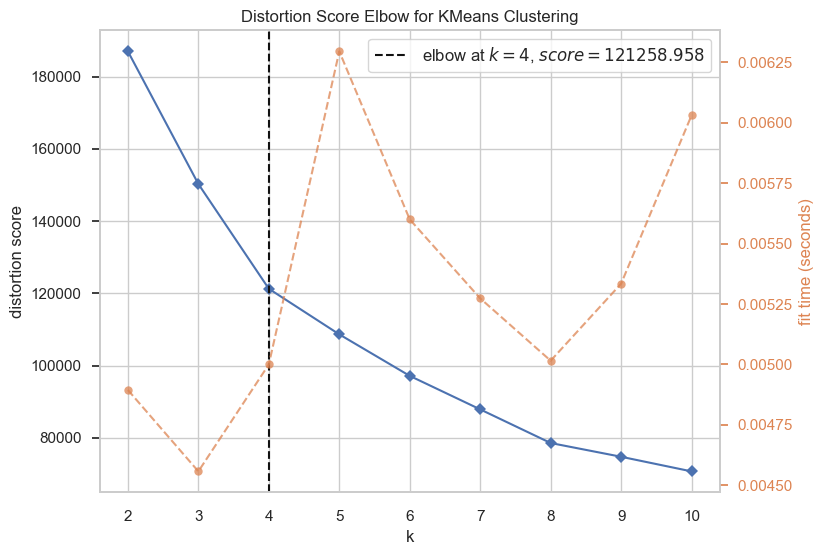

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [137]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

plt.figure(figsize=(8,6), dpi=100)
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(pdf)
Elbow_M.show()

**Interpretation:**
- Choose k = 4 is likely the most efficient balance between having a manageable number of clusters and minimizing distortion.
- The green line represents the fit time, which remains relatively stable across different k values, indicating that computation time isn't a significant factor in deciding k.

**Conclusion:** <br>
The elbow method suggesting that using 4 clusters is optimal for this dataset, as it balances complexity and fit quality effectively.

# Agglomerative Clustering

In [138]:
from sklearn.cluster import AgglomerativeClustering

AC = AgglomerativeClustering(n_clusters=4)
yhat_AC = AC.fit_predict(pdf)
pdf["Clusters"] = yhat_AC

# Create new series for clusters with same index as original due to drop duplicates
clusters_series = pd.Series(index=original_indices)
clusters_series.loc[df_model.index] = yhat_AC # assigning the cluster labels where there are non NaN values
df['Clusters'] = clusters_series

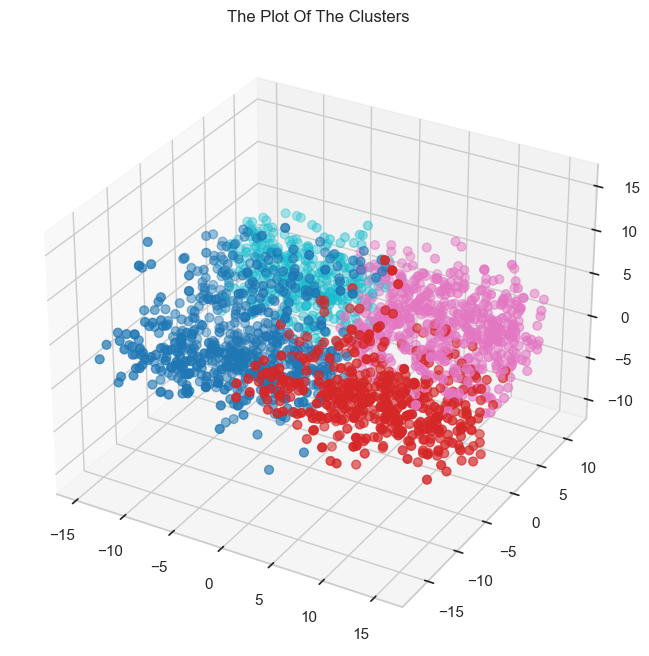

In [139]:
fig = plt.figure(figsize=(10,8), dpi=100)
ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=pdf["Clusters"], marker='o', cmap= 'tab10')
ax.set_title("The Plot Of The Clusters")
plt.show()

# Model Evaluation

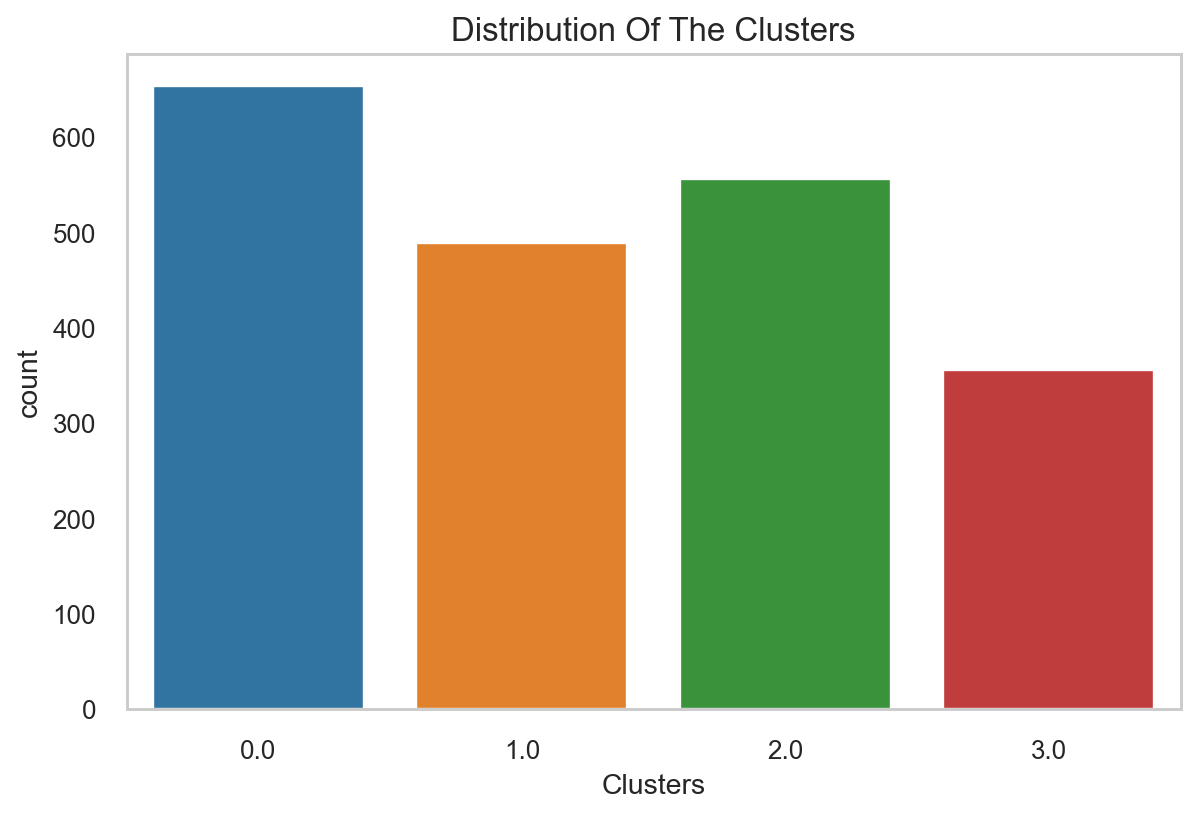

In [140]:
plt.figure(figsize=(8,5), dpi=170)
sns.countplot(x=df["Clusters"], palette= 'tab10')
plt.title("Distribution Of The Clusters", fontsize=14)
plt.grid(False)
plt.show()

**Findings:**
- The top cluster's distribution is cluster 0
- As the 2nd top cluster's distribution is cluster 2

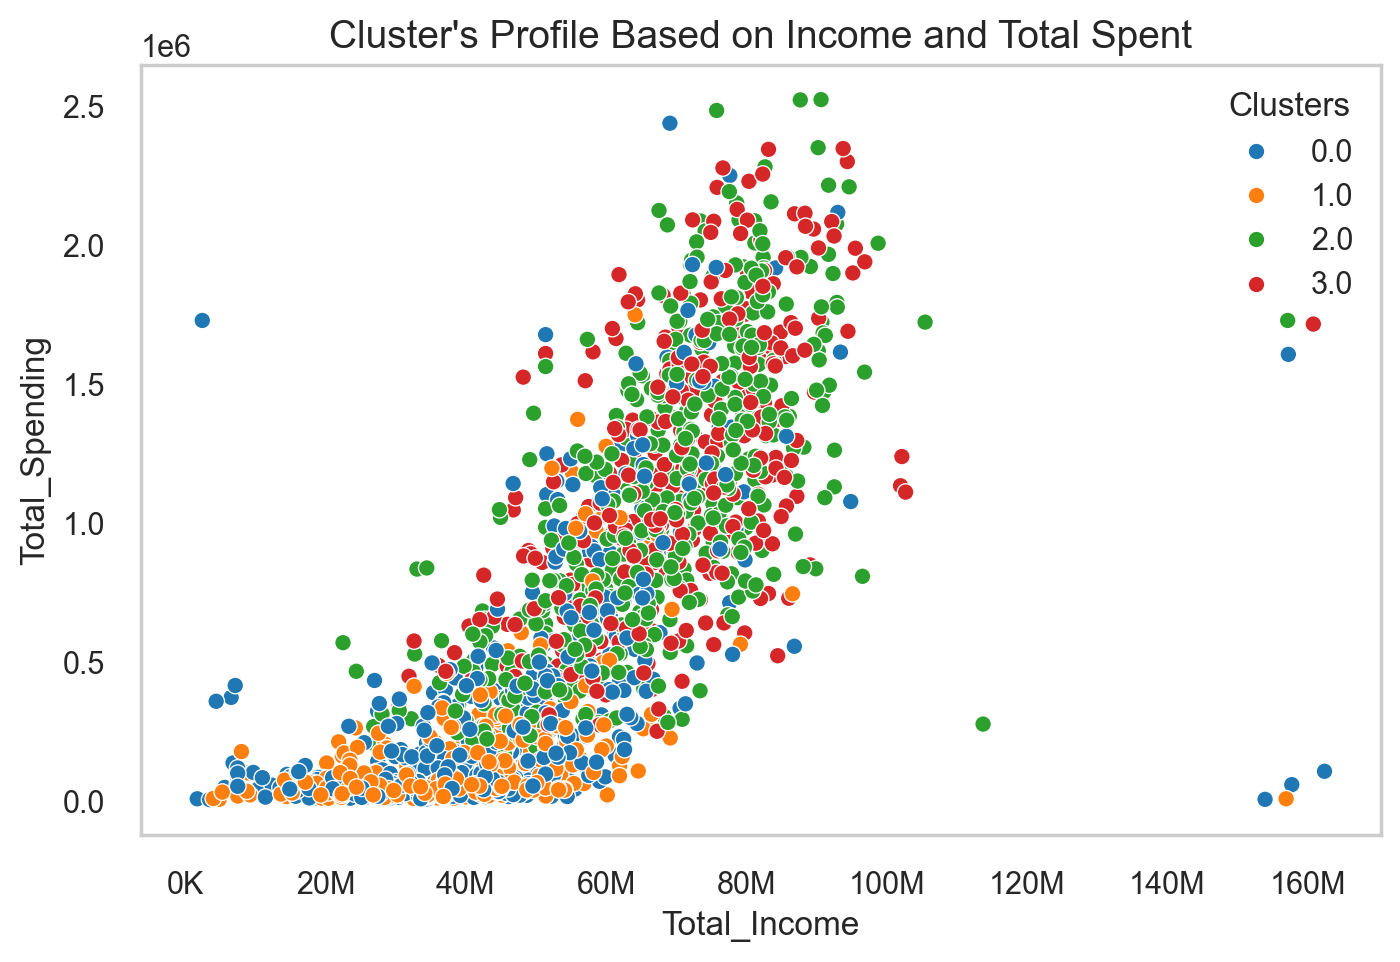

In [141]:
import numpy as np
import matplotlib.ticker as ticker

df['Total_Income'] = np.expm1(df['Income'])

plt.figure(figsize=(8,5), dpi=200)
sns.scatterplot(data=df, x='Total_Income', y='Total_Spending', hue='Clusters', palette='tab10')
plt.title("Cluster's Profile Based on Income and Total Spent", fontsize=14)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x / 1e6)}M' if x >= 1e6 else f'{int(x / 1e3)}K'))

plt.grid(False)
plt.show()

**Findings:**
- Cluster 0: Middle-Low Income & Low Spending
- Cluster 1: Low Income & Low Spending
- Cluster 2: Middle-High Income & High Spending
- Cluster 3: High Income & High Spending

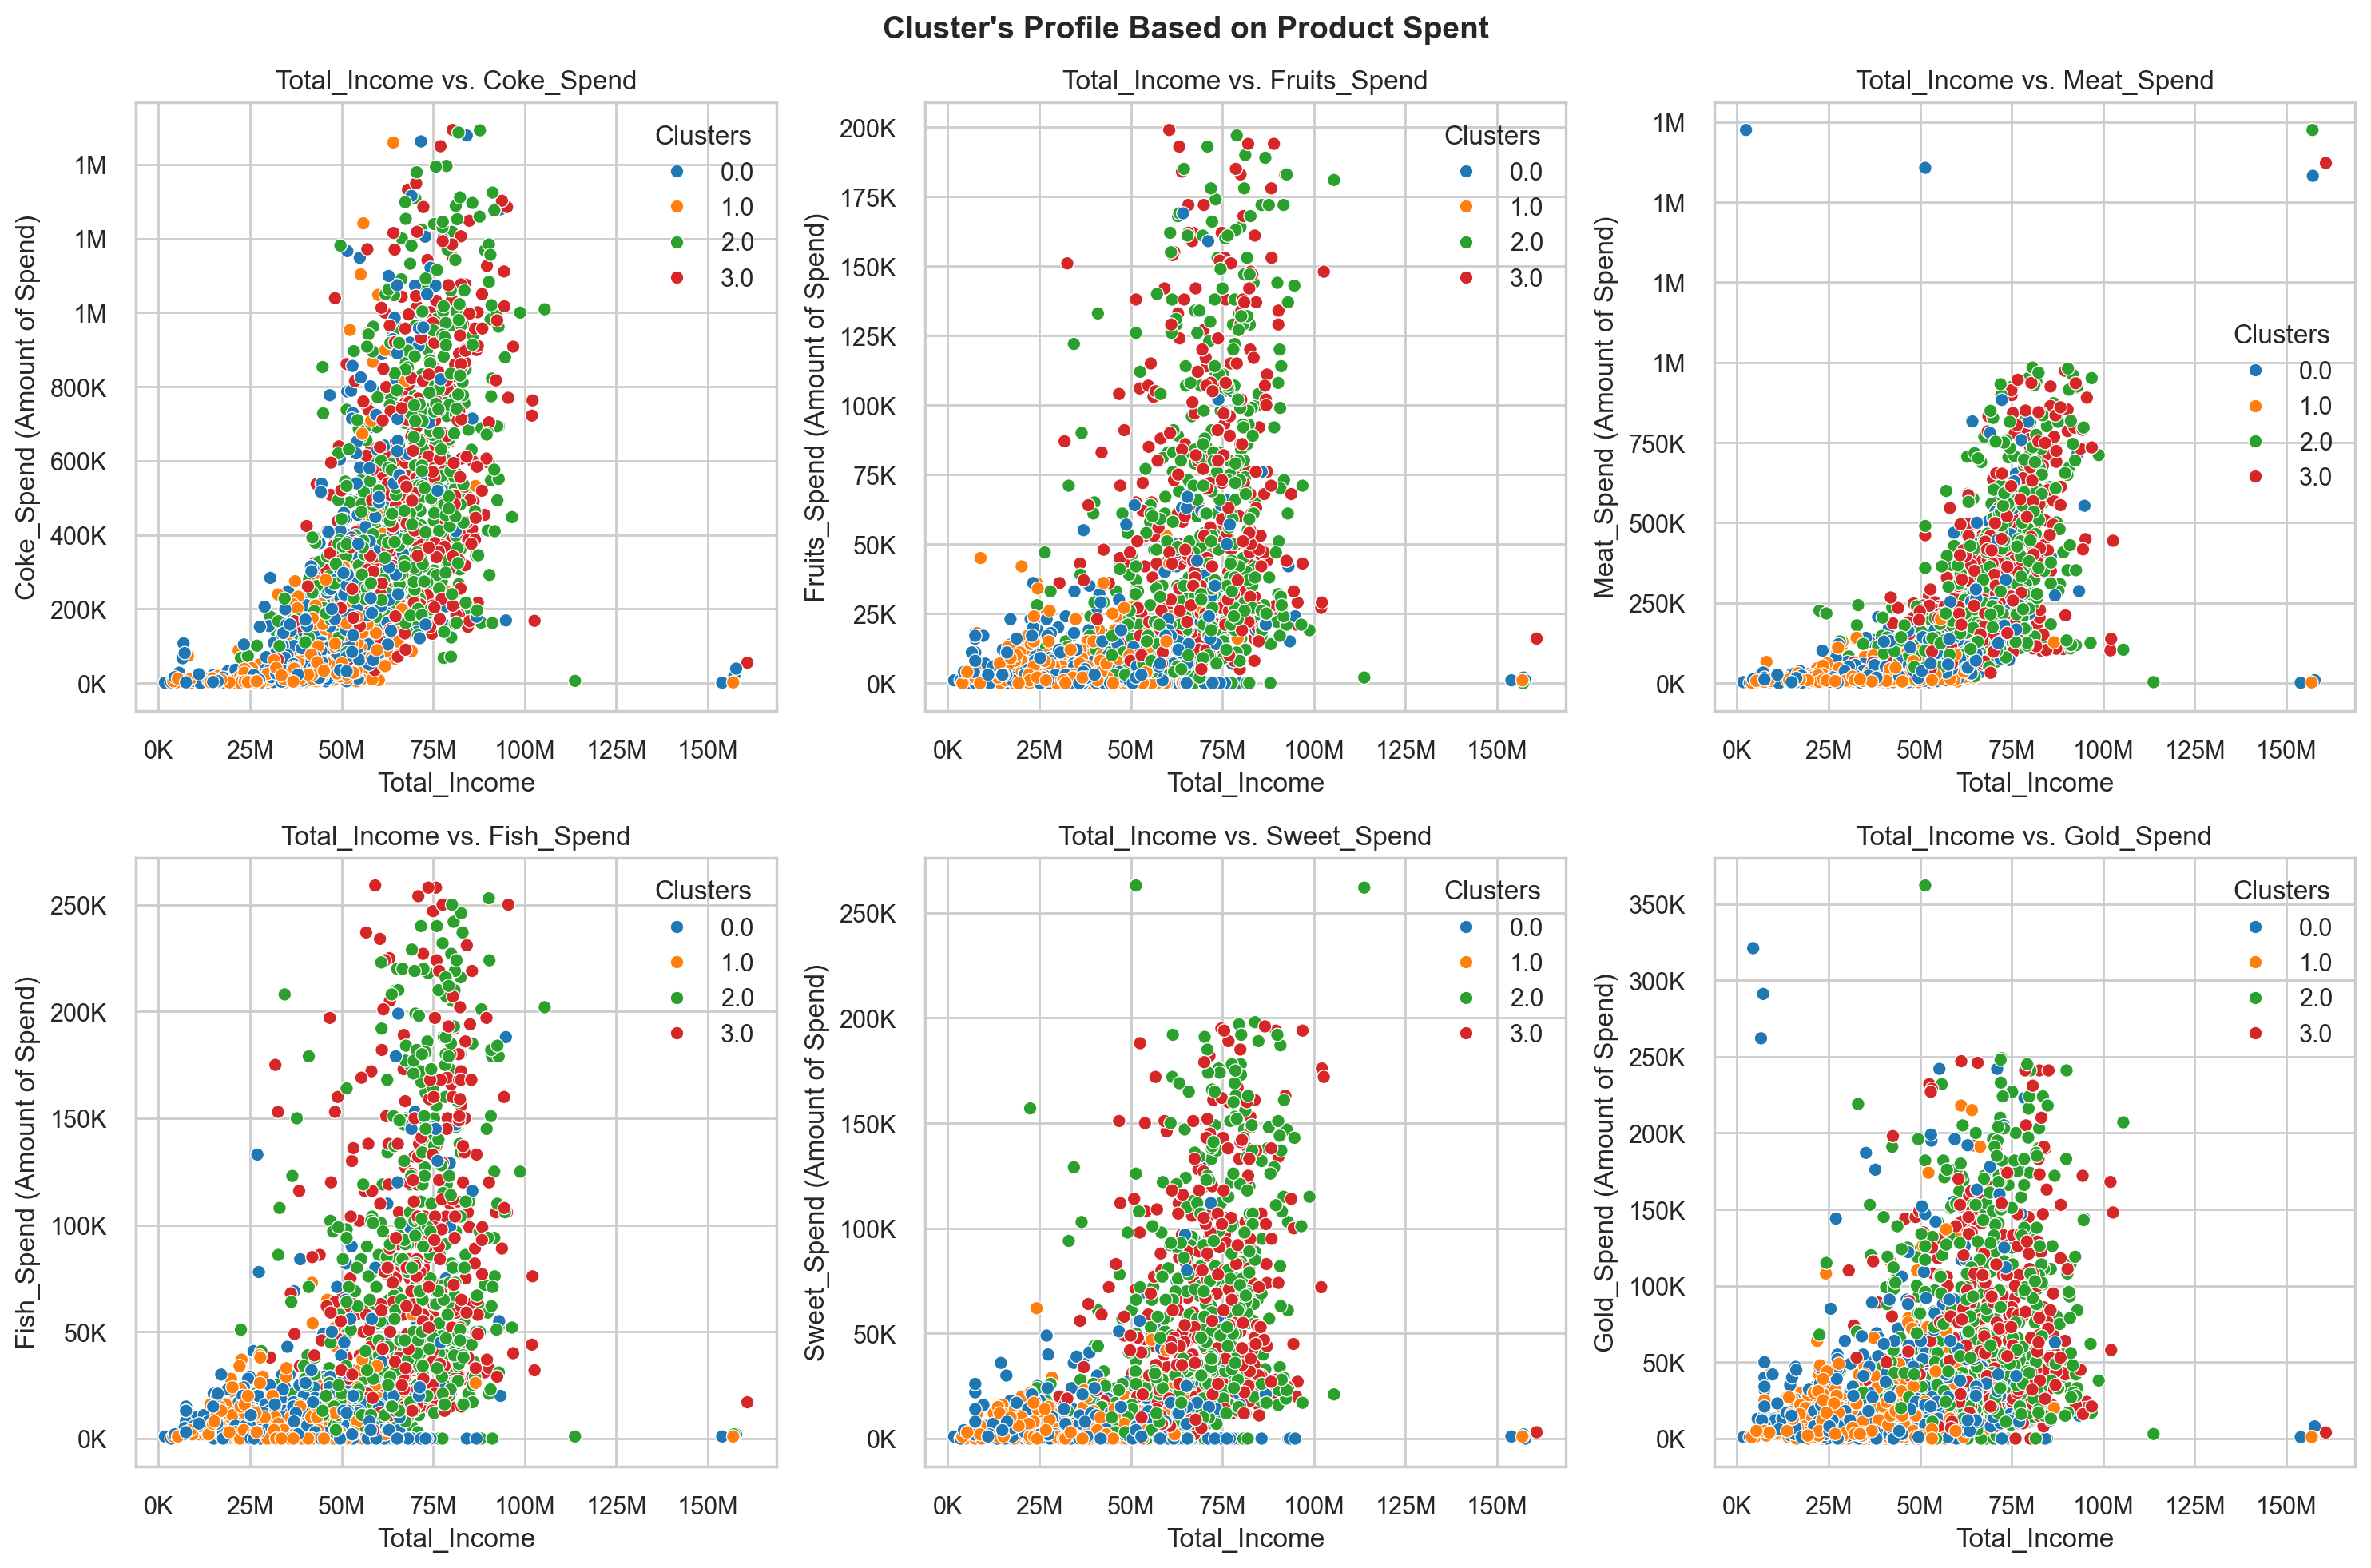

In [142]:

# Revert log transform
df['Coke_Spend'] = np.expm1(df['Coke'])
df['Fruits_Spend'] = np.expm1(df['Fruits'])
df['Meat_Spend'] = np.expm1(df['Meat'])
df['Fish_Spend'] = np.expm1(df['Fish'])
df['Sweet_Spend'] = np.expm1(df['Sweet'])
df['Gold_Spend'] = np.expm1(df['Gold'])

col = ['Coke_Spend', 'Fruits_Spend', 'Meat_Spend', 'Fish_Spend', 'Sweet_Spend', 'Gold_Spend']

num_cols = 3
num_rows = (len(col) // num_cols) + (len(col) % num_cols > 0)

df_drop = df.copy()
df_drop = df_drop.drop(df_drop[df_drop['Total_Income'] == df_drop['Total_Income'].max()].index)

plt.figure(figsize=(15, num_rows * 5), dpi=200)
plt.suptitle("Cluster's Profile Based on Product Spent", fontsize=14, fontweight='bold')
for i, product in enumerate(col):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(data=df_drop, x='Total_Income', y=product, hue='Clusters', palette='tab10')
    plt.title(f'Total_Income vs. {product}')
    plt.xlabel('Total_Income')
    plt.ylabel(f'{product} (Amount of Spend)')
    
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x / 1e6)}M' if x >= 1e6 else f'{int(x / 1e3)}K'))
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y / 1e6)}M' if y >= 1e6 else f'{int(y / 1e3)}K'))

plt.tight_layout()
# plt.savefig("Customer's Spend Amount on Products (Drop Extreme Outliers)", dpi=300, bbox_inches='tight')
plt.show()

**Findings:**
- **Lower Income Group (Cluster 1):** <br>This group tends to purchase a variety of products, but their meat purchases are notably low. This may be due to the higher cost of meat, which might not be affordable for this income bracket.<br>

- **Middle-Low Income Group (Cluster 0):** <br>They show a strong preference for Coke and Gold products over others. This could indicate a focus on affordable luxuries and investments.<br>

- **Middle-High Income Group (Cluster 2):** <br>There is a significant interest in Coke products, with spending surpassing one million. This suggests a preference for certain branded items or bulk purchasing.<br>

- **High Income Group (Cluster 3):** <br>This group demonstrates a balanced interest across all product categories, indicating diverse purchasing power and preferences.<br>

- **Meat Purchases:** <br>Expensive products like meat are predominantly purchased by middle to high-income individuals, while lower-income groups focus on more affordable items like Coke, Fruits, and Fish.<br>

- **Gold Investment:** <br>All clusters show an interest in gold, highlighting an overall awareness and interest in investment opportunities among customers.<br>

- **Cluster Dynamics:** <br>The spending patterns suggest that each cluster has distinct purchasing behaviors, which can be leveraged for targeted marketing strategies.<br>

- **Product Pricing Strategy:** <br>Adjusting product pricing and promotions based on cluster preferences could optimize sales and customer satisfaction.<br>

- **Potential for Cross-Selling:** <br>Understanding these preferences can also aid in cross-selling strategies, especially targeting lower-income groups with affordable versions of higher-end products.<br>

- **Customer Engagement:** <br>The interest in gold investment across all clusters suggests potential for financial products or services tailored to different income levels.<br>

Text(0.5, 1.02, 'Cluster 2 total spending distribution is more diverse than the other cluster')

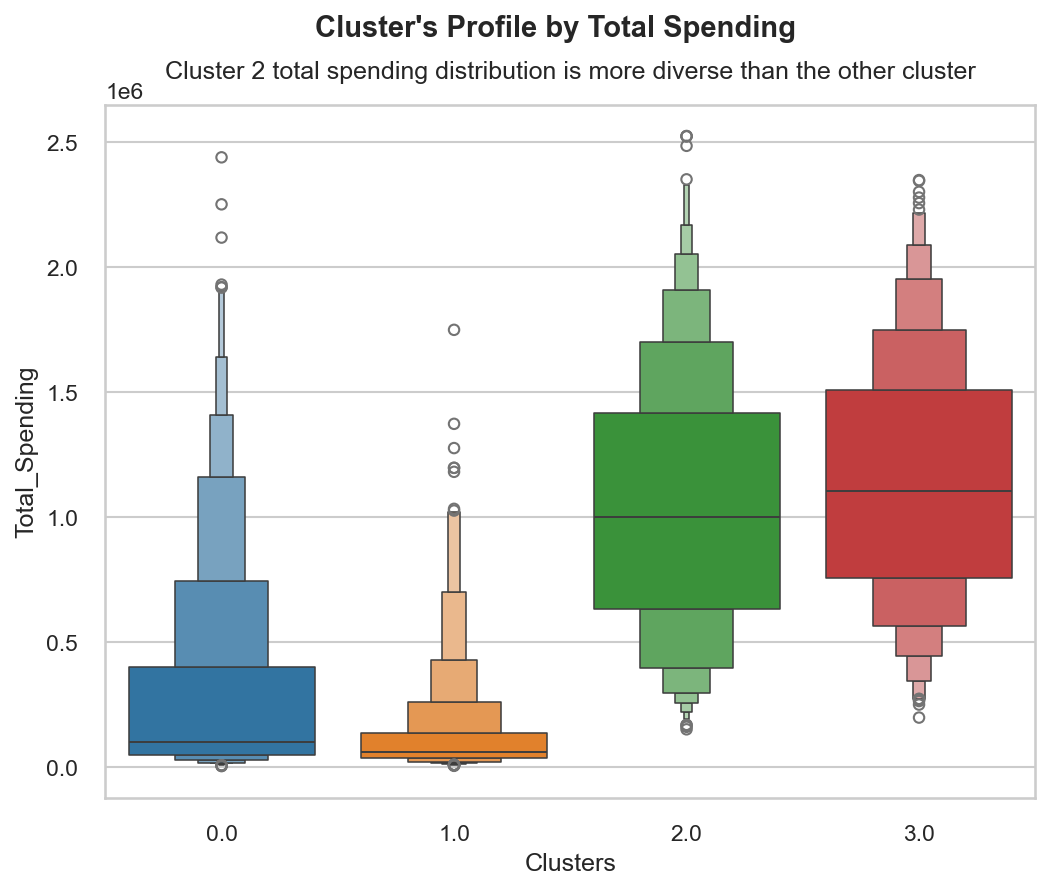

In [143]:
plt.figure(figsize=(8,6), dpi=150)
sns.boxenplot(x=df["Clusters"], y=df["Total_Spending"], palette='tab10')
plt.suptitle("Cluster's Profile by Total Spending", fontsize=14, fontweight='bold')
plt.title("Cluster 2 total spending distribution is more diverse than the other cluster", y=1.02)

**Findings:**
- **Purchase Behavior:** <br>
Cluster 0 and 1, with middle to lower income, tend to purchase a lower price products. Then, cluster 3's purchase behavior tend to buy a higher price products and cluster 2 is more diverse in their purchase behavior. <br>
- **Marketing Strategy:** <br>
    - Cross-selling products for cluster 2 since their purchase behavior are variate, we can offer other products.
    - Bundling strategy because our customers are interested in all products categories.
    - Offer more values for market on cluster 3, such as premium quality Meat.


In [144]:
def get_last_campaign(row):
    if row['Campaign_5'] == 1:
        return 5
    elif row['Campaign_4'] == 1:
        return 4
    elif row['Campaign_3'] == 1:
        return 3
    elif row['Campaign_2'] == 1:
        return 2
    elif row['Campaign_1'] == 1:
        return 1
    else:
        return 0  # No campaign accepted
    
df['Last_Campaign'] = df.apply(get_last_campaign, axis=1)
grouped_data = df.groupby(['Last_Campaign', 'Clusters']).size().reset_index(name='Counts')


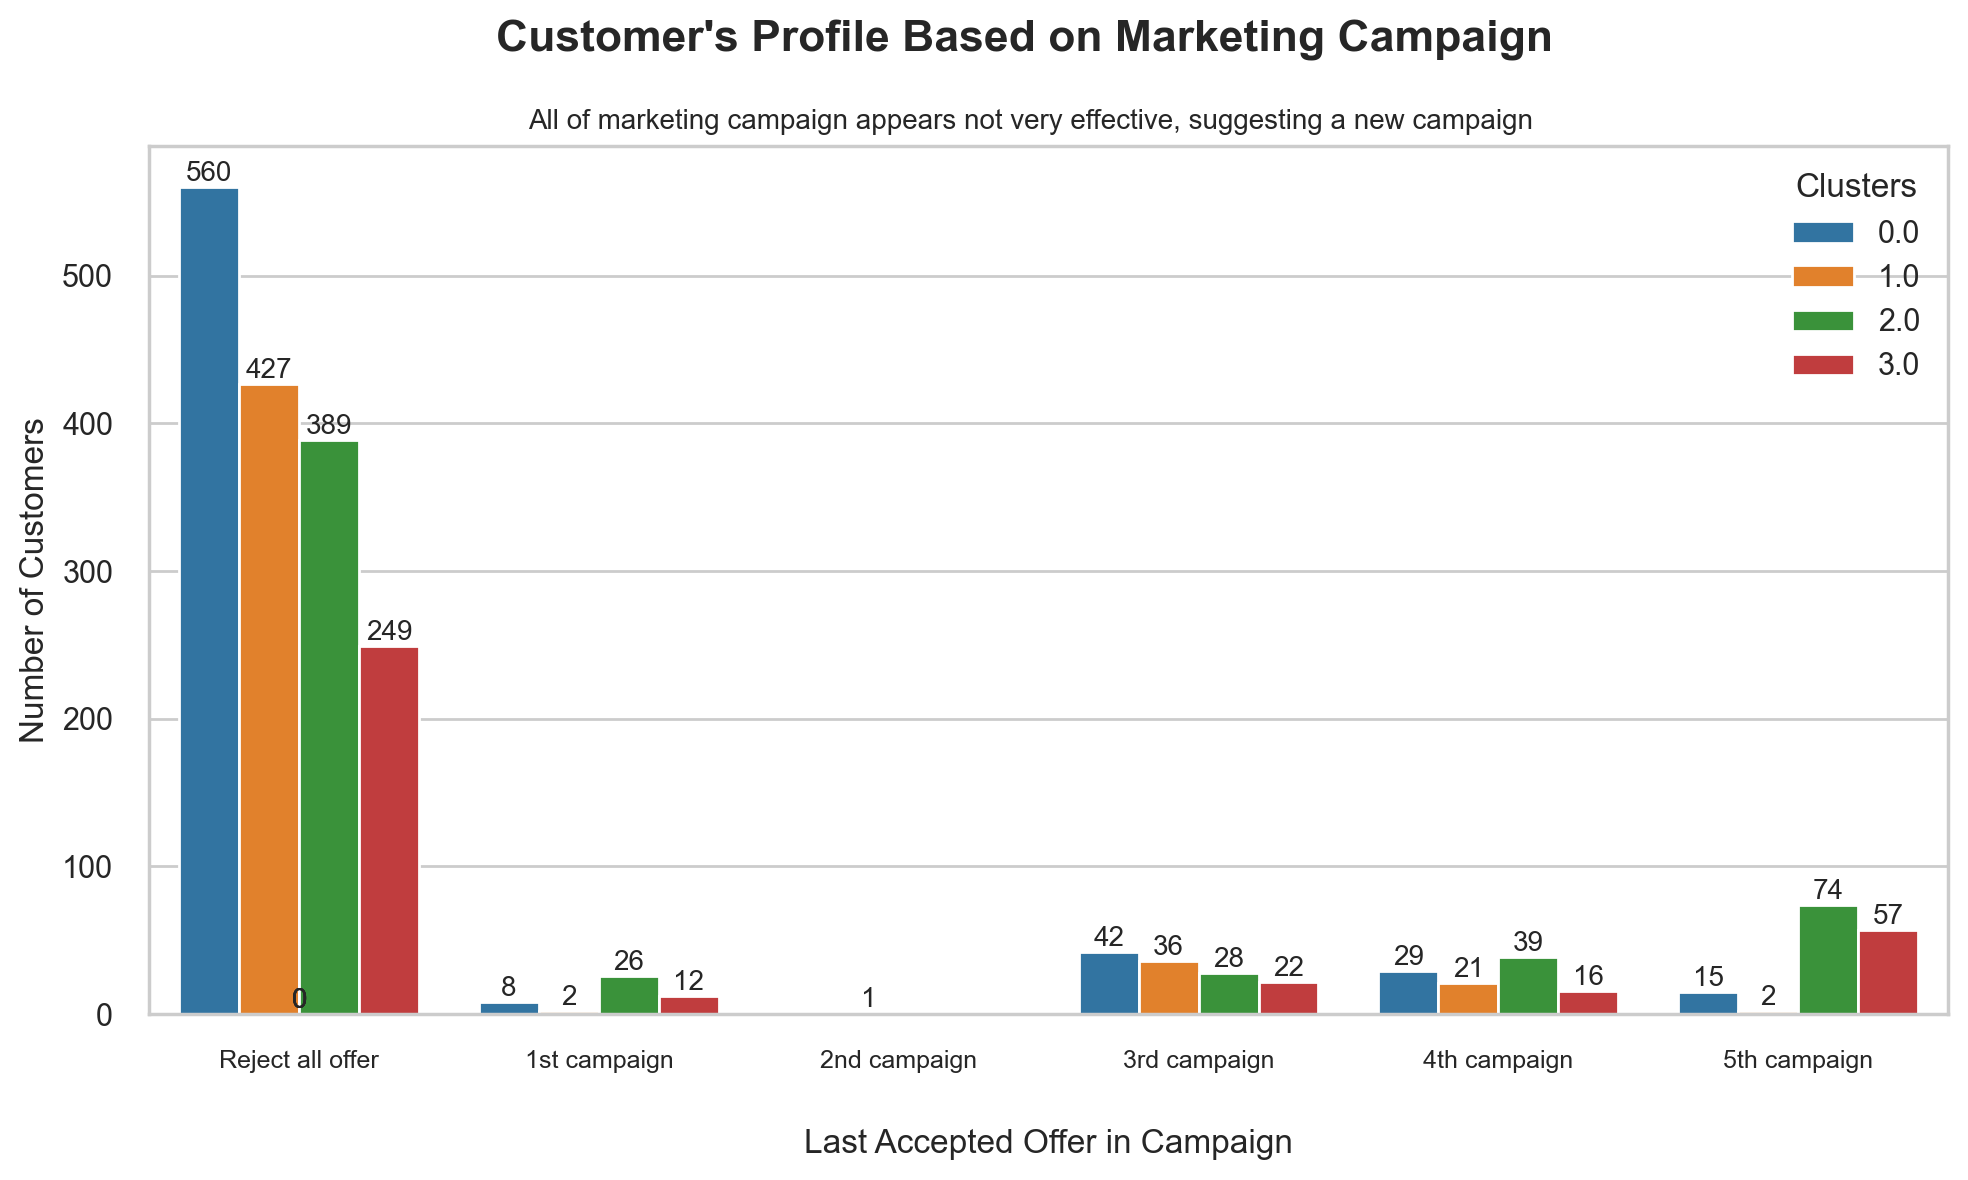

In [145]:
plt.figure(figsize=(10, 6), dpi=200)
barplot = sns.barplot(data=grouped_data, x='Last_Campaign', y='Counts', hue='Clusters', palette='tab10')

for p in barplot.patches:
    plt.annotate(f'{int(p.get_height())}', 
                 (p.get_x() + p.get_width() / 2, p.get_height()), 
                 ha='center', va='bottom', fontsize=10)

plt.suptitle("Customer's Profile Based on Marketing Campaign", fontsize=16, fontweight='bold', x=0.52)
plt.title("All of marketing campaign appears not very effective, suggesting a new campaign", fontsize=10, ha='center', x=0.49)
plt.xlabel('Last Accepted Offer in Campaign', fontsize=12, labelpad=20)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks([0,1,2,3,4,5], ['Reject all offer',
                           '1st campaign',
                           '2nd campaign',
                           '3rd campaign',
                           '4th campaign',
                           '5th campaign'], fontsize=9)
plt.tight_layout()
plt.savefig("Effectiveness of Marketing Campaigns Based on Last Response", dpi=300, bbox_inches='tight')
plt.show()

**Findings:**
- **Campaign Effectiveness:**<br>
All of customers dominantly reject offering in every campaign. There are only a few customers who accept the offer, especially the 2nd campaign. This insight suggesting that the company should create a new marketing strategy campaign. The fifth campaign have a better results for cluster 2 and cluster 3 while the third campaign have a high positive response from cluster 0. 
- **Campaign Strategy:** <br>
Looking at the pattern in every campaign, it is likely the campaign order does not affect customer's purchase behavior. Meaning, the more customer offered through campaign does not mean the customer will accept the offer. Thus, company should focus offering products based on customer's characteristic. E.g.:
    - Offering a high value products for cluster 3 because this cluster is a high spender with high income
    - Offer bundling and cross-selling products for cluster 2 because this cluster is more diverse in their total spend.
    - Offer a promotion for cluster 0 and 1 because these clusters are middle-low income, meaning price will be their first consideration


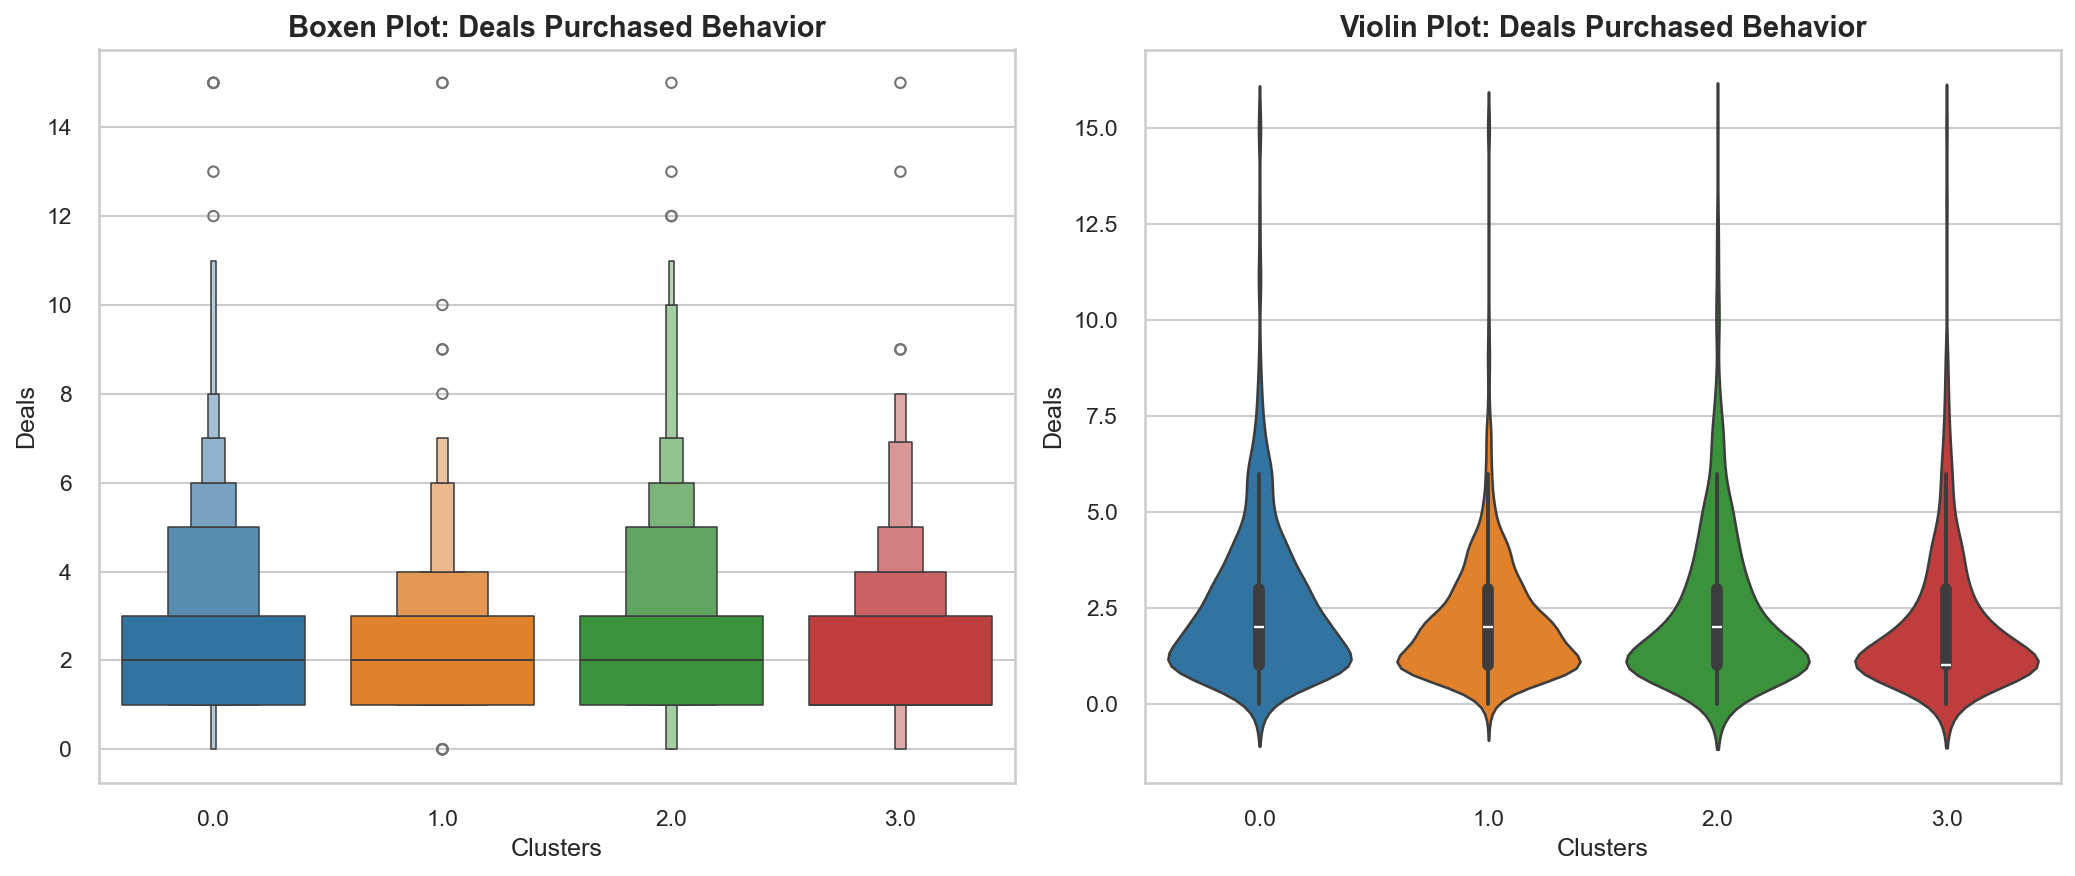

In [146]:
plt.figure(figsize=(14, 6), dpi=150)

# Boxen Plot
plt.subplot(1, 2, 1)
sns.boxenplot(y=df["Deals_Purchases"], x=df["Clusters"], palette='tab10')
plt.title("Boxen Plot: Deals Purchased Behavior", fontsize=14, fontweight='bold')
plt.xlabel("Clusters")
plt.ylabel("Deals")

# Violin Plot
plt.subplot(1, 2, 2)
sns.violinplot(y=df["Deals_Purchases"], x=df["Clusters"], palette='tab10')
plt.title("Violin Plot: Deals Purchased Behavior", fontsize=14, fontweight='bold')
plt.xlabel("Clusters")
plt.ylabel("Deals")

plt.tight_layout()
plt.show()

**Findings:**
- Middle-low income (Cluster 0) and Middle-high income (Cluster 2) are group of people who purchased deals / discounted products.
- Company can make a bundle or deals that targeting middle income (Cluster 0 and 2) since they are a high spender instead of other clusters.

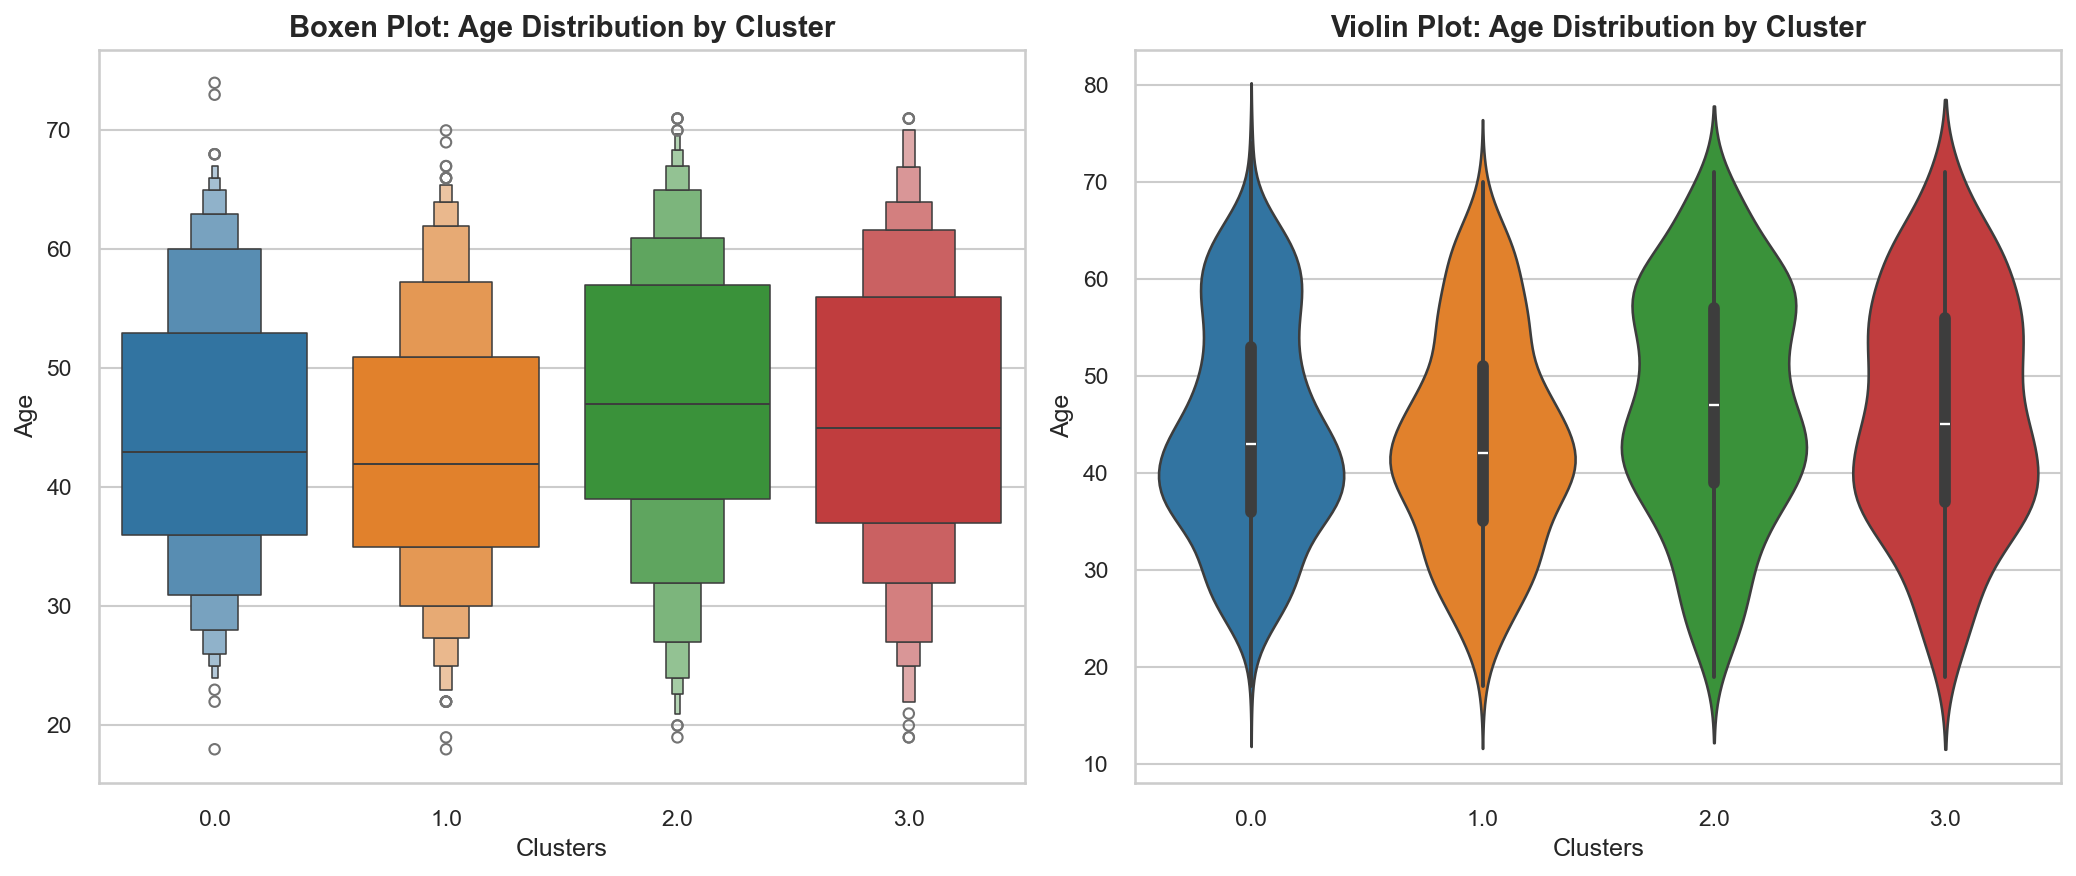

,count,mean,std,min,25%,50%,75%,max
Clusters,,,,,,,,
0.0,654.0,44.420295,11.330896,17.993378,35.997758,42.999461,53.001893,74.007002
1.0,487.0,43.243873,11.024911,17.993378,34.997514,41.999217,51.001407,70.006029
2.0,555.0,46.894102,12.046378,18.993622,38.998487,47.000434,57.002867,71.006273
3.0,356.0,46.185629,12.114373,18.993622,36.998001,44.999947,56.002623,71.006273


In [147]:
# Original mean and standard deviation
original_mean = 45.218872
original_std_dev = 11.977991
df['Usia'] = df['Age'] * original_std_dev + original_mean
top_3_ages = df['Usia'].nlargest(3).unique()
df = df[~df['Usia'].isin(top_3_ages)] # Remove Outliers

plt.figure(figsize=(14, 6), dpi=150)

# Boxen Plot
plt.subplot(1, 2, 1)
sns.boxenplot(y=df["Usia"], x=df["Clusters"], palette='tab10')
plt.title("Boxen Plot: Age Distribution by Cluster", fontsize=14, fontweight='bold')
plt.xlabel("Clusters")
plt.ylabel("Age")

# Violin Plot
plt.subplot(1, 2, 2)
sns.violinplot(y=df["Usia"], x=df["Clusters"], palette='tab10')
plt.title("Violin Plot: Age Distribution by Cluster", fontsize=14, fontweight='bold')
plt.xlabel("Clusters")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

cluster_age = df.groupby('Clusters')['Usia'].describe()
cluster_age

**Findings:**
- There are no significant different between clusters
- 75% customers' age in every clusters is under 56 years old

# Profilling

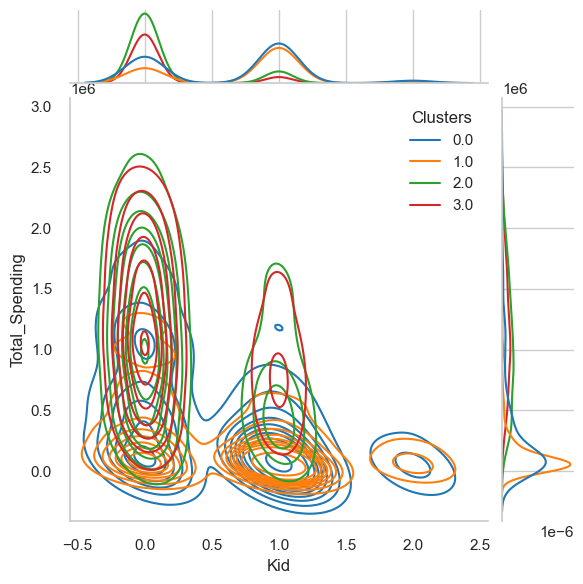

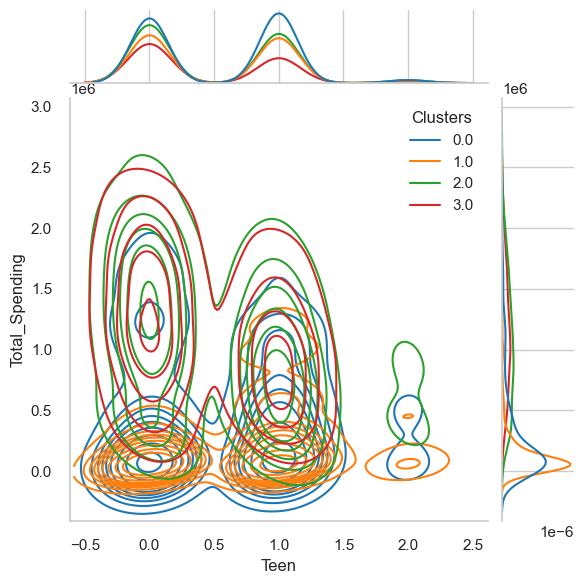

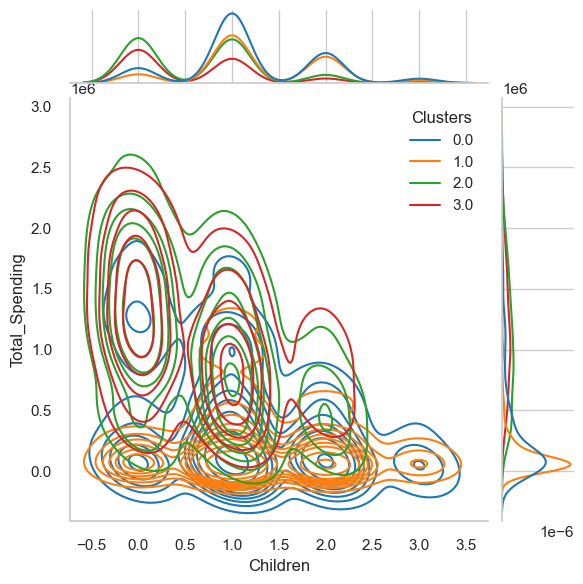

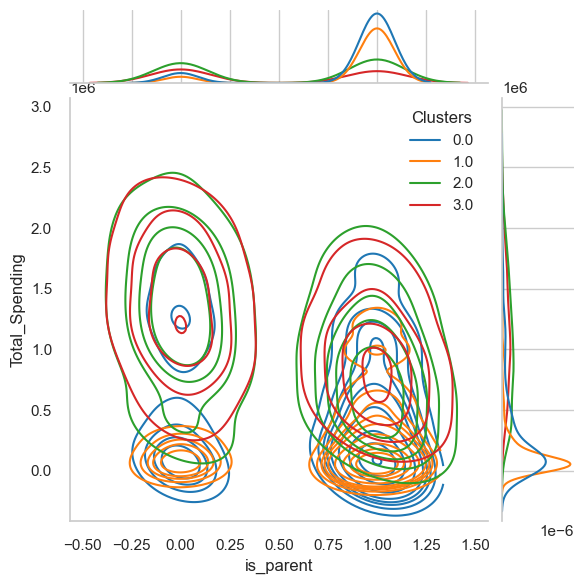

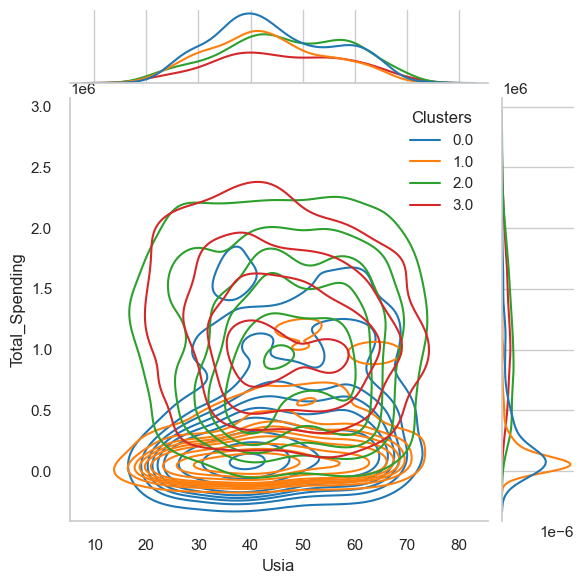

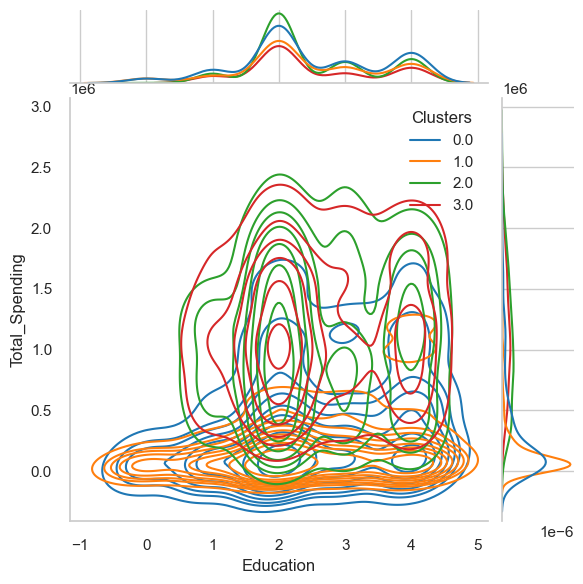

In [ ]:
personal_information = ['Kid', 'Teen', 'Children', 'is_parent', 'Usia']

for i in personal_information:
    g = sns.jointplot(data=df, x=i, y='Total_Spending', hue='Clusters', kind='kde', palette='tab10')
    g.ax_joint.grid(False)
    plt.show()

# Conclusion:
The following information can explain customers' profile based on their total spending:<br>
**1. Cluster 0:**
- Most of them are a parent and some customers who are not a parent tend a bit high spending
- Mostly have 1 children
- Teenage more dominated than having a kid
- Customers with age around 30 - 40 tend to have a high spending<br>

**2. Cluster 1:**
- Dominantly are a parent and have a high spending than non parent
- Mostly have 1 children
- Teenage more dominated than having a kid
- Customers with age around 50 - 60 tend to have a high spending<br>

**3. Cluster 2:**
- The parent status tend to equal with non parent has a high total spending than customers who are a parent
- Customers who are a parent mostly have 1 children but they who do not have children are high spender
- Teenage more dominated than having a kid
- Their age distribution are vary<br>

**4. Cluster 3:**
- Mostly are non parent
- Domantly do not have a child
- Teenage more dominated than having a kid
- 40 years old customers have a highest spent<br>